<a href="https://colab.research.google.com/github/shaikhdaiyaan251-cloud/CODE-ALPHA-MACHINE-LEARNING-INTERNSHIP-TASK-2/blob/main/MACHINE_LEARNING_INTERNSHIP_TASK_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TASK 2: EMOTION RECOGNITION FROM SPEECH**
## **2.1. Setting up the Environment**
## **2.2. Loading and Exploring the Dataset**
## **2.3. Feature Extraction (MFCCs)**
## **2.4. Splitting and Preparing Data**
## **2.5. Building Deep Learning Model**
## **2.6. Training the Model**
## **2.7. Evaluating the Model**
## **2.8. Live Testing**


## **2.1. Setting up the Environment**


In [ ]:
# ==============================================
# TASK 2 - Emotion Recognition from Speech
# Environment Setup (Local Upload Version)
# ==============================================

# 1. Install missing libraries
!pip install librosa --quiet
!pip install kagglehub --quiet          # kept in case you later want to download directly

# 2. Import core libraries
import os
import sys
import random
import zipfile
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Audio processing
import librosa
import librosa.display
import soundfile as sf
from IPython.display import Audio, display

# For local file upload
from google.colab import files

# Machine learning & preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.utils import to_categorical

# Deep learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, Activation, Flatten,
    Conv2D, MaxPooling2D, BatchNormalization,
    LSTM, TimeDistributed, Input, Reshape
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

# 3. Check GPU availability
print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("✅ GPU is available:", gpus)
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("❌ GPU not found! Go to Runtime > Change runtime type > GPU.")

# 4. Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 5. Plot aesthetics
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

print("\n✅ Environment setup complete. Ready for local upload!")

# ==============================================
# Upload dataset zip from local computer
# ==============================================

print("📁 Please upload the zip file containing your dataset (e.g., RAVDESS.zip)")
uploaded = files.upload()  # Opens file picker dialog

# Get the uploaded filename (assumes single zip file)
zip_filename = list(uploaded.keys())[0]
print(f"✅ Uploaded: {zip_filename} ({len(uploaded[zip_filename])} bytes)")

# Extract into a folder (e.g., 'dataset')
extract_dir = "/content/dataset"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(io.BytesIO(uploaded[zip_filename]), 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# List extracted contents
extracted_items = os.listdir(extract_dir)
print("📂 Extracted contents:", extracted_items)

TensorFlow version: 2.19.0
✅ GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

✅ Environment setup complete. Ready for local upload!
📁 Please upload the zip file containing your dataset (e.g., RAVDESS.zip)


Saving archive (8).zip to archive (8).zip
✅ Uploaded: archive (8).zip (450102890 bytes)
📂 Extracted contents: ['Actor_12', 'Actor_17', 'Actor_05', 'Actor_07', 'Actor_01', 'Actor_13', 'Actor_18', 'Actor_08', 'Actor_23', 'Actor_20', 'Actor_02', 'Actor_22', 'Actor_14', 'Actor_10', 'Actor_21', 'Actor_24', 'audio_speech_actors_01-24', 'Actor_03', 'Actor_16', 'Actor_09', 'Actor_04', 'Actor_06', 'Actor_19', 'Actor_11', 'Actor_15']


## **2.2. Loading and Exploring the Dataset**


📁 Total audio files found: 2880
✅ Parsed 2880 files.



/tmp/ipykernel_2186/4208190817.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=emotion_counts, x='Emotion', y='Count', palette='viridis')


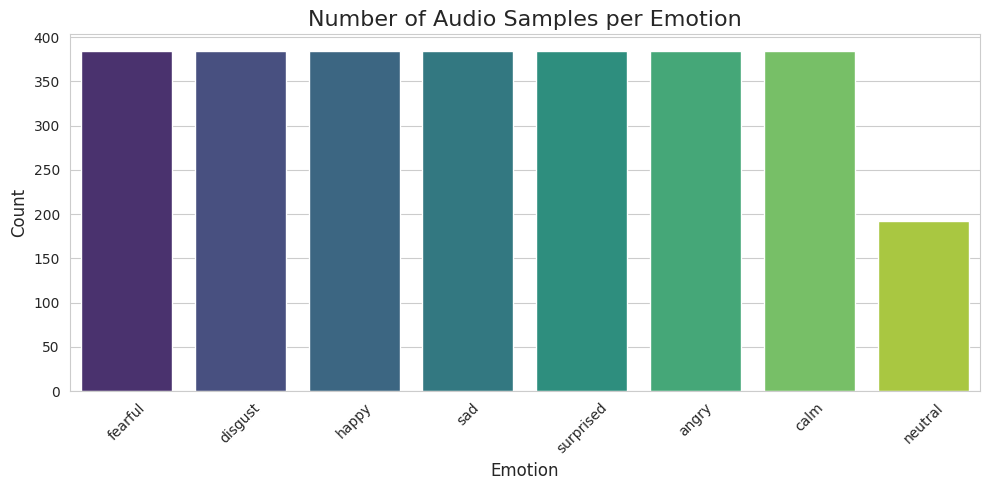

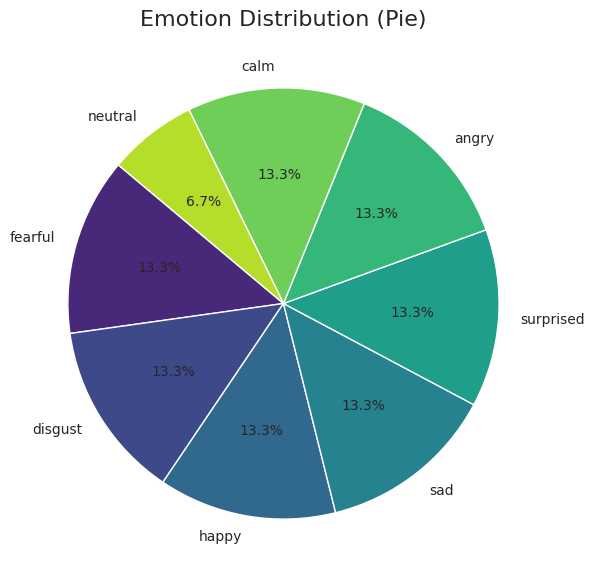

🎵 Sample: 03-01-06-02-01-02-12.wav
   Emotion: fearful, Actor: 12
   Length: 3.70s, Sample rate: 48000 Hz


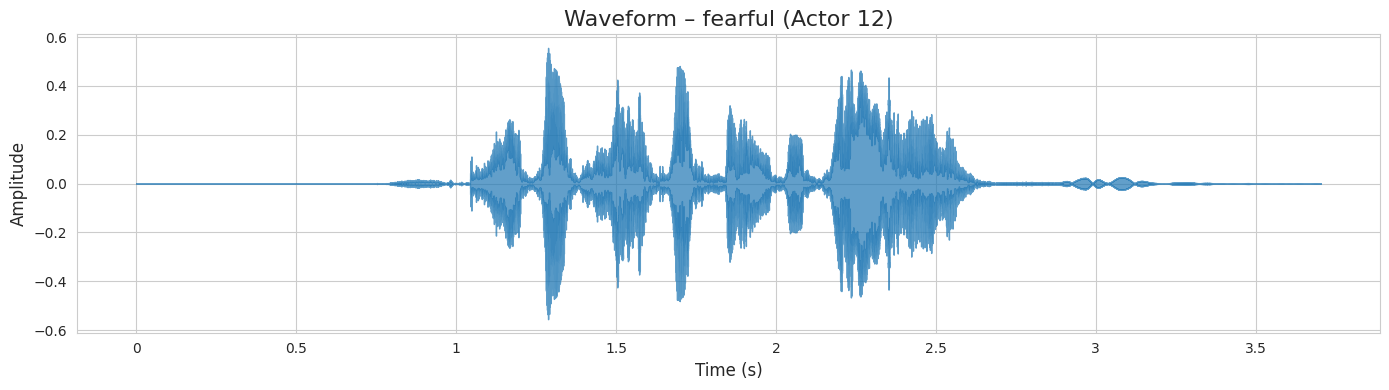

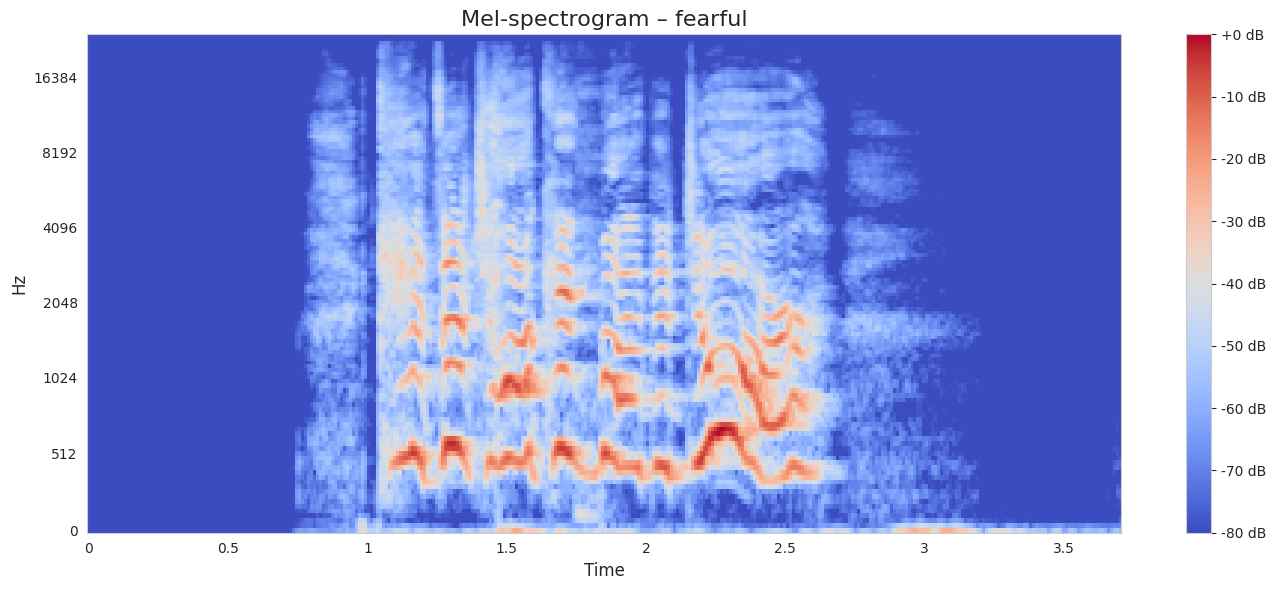

⏱️  Duration stats: min=2.94s, max=5.27s, mean=3.70s


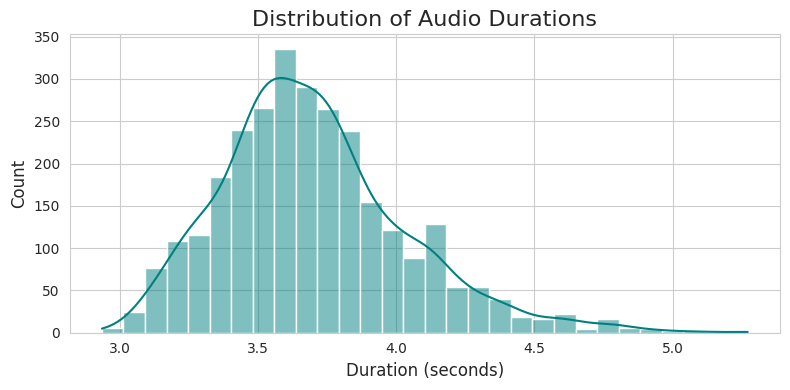

In [ ]:
# ==============================================
# STEP 2: Loading and Exploring the RAVDESS Dataset
# ==============================================

# ---------- 2.1 Collect audio file paths ----------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from IPython.display import Audio, display

base_dir = "/content/dataset"   # change if your extracted folder name differs
audio_paths = []
for root, dirs, files in os.walk(base_dir):
    for file in files:
        if file.endswith(".wav"):
            audio_paths.append(os.path.join(root, file))

print(f"📁 Total audio files found: {len(audio_paths)}")

# ---------- 2.2 Parse filenames & build dataframe ----------
emotion_map = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}

data = []
for path in audio_paths:
    filename = os.path.basename(path)
    parts = filename[:-4].split('-')          # e.g., ['03','01','06','01','02','01','12']
    if len(parts) == 7:
        data.append({
            'filepath': path,
            'emotion_id': parts[2],
            'emotion': emotion_map[parts[2]],
            'intensity': parts[3],
            'statement': parts[4],
            'repetition': parts[5],
            'actor': int(parts[6])
        })

df = pd.DataFrame(data)
print(f"✅ Parsed {len(df)} files.\n")
df.head(8)

# ---------- 2.3 Emotion distribution (bar + pie) ----------
emotion_counts = df['emotion'].value_counts().reset_index()
emotion_counts.columns = ['Emotion', 'Count']

# Bar chart
plt.figure(figsize=(10,5))
sns.barplot(data=emotion_counts, x='Emotion', y='Count', palette='viridis')
plt.title('Number of Audio Samples per Emotion')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pie chart
plt.figure(figsize=(7,7))
plt.pie(emotion_counts['Count'], labels=emotion_counts['Emotion'],
        autopct='%1.1f%%', startangle=140,
        colors=sns.color_palette('viridis', len(emotion_counts)))
plt.title('Emotion Distribution (Pie)')
plt.show()

# ---------- 2.4 Audio sample: waveform, mel-spectrogram & playback ----------
sample_idx = 0   # change to hear/see any file
sample_path = df['filepath'].iloc[sample_idx]
audio, sr = librosa.load(sample_path, sr=None)   # original sample rate

print(f"🎵 Sample: {os.path.basename(sample_path)}")
print(f"   Emotion: {df['emotion'].iloc[sample_idx]}, Actor: {df['actor'].iloc[sample_idx]}")
print(f"   Length: {len(audio)/sr:.2f}s, Sample rate: {sr} Hz")

# Audio player
display(Audio(audio, rate=sr))

# Waveform
plt.figure(figsize=(14,4))
librosa.display.waveshow(audio, sr=sr, alpha=0.7)
plt.title(f"Waveform – {df['emotion'].iloc[sample_idx]} (Actor {df['actor'].iloc[sample_idx]})")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

# Mel-spectrogram
mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
db_mel = librosa.power_to_db(mel_spec, ref=np.max)

plt.figure(figsize=(14,6))
librosa.display.specshow(db_mel, sr=sr, x_axis='time', y_axis='mel', cmap='coolwarm')
plt.colorbar(format='%+2.0f dB')
plt.title(f"Mel-spectrogram – {df['emotion'].iloc[sample_idx]}")
plt.tight_layout()
plt.show()

# ---------- 2.5 Duration statistics ----------
durations = []
for path in df['filepath']:
    y, sr = librosa.load(path, sr=None)
    durations.append(len(y)/sr)

df['duration'] = durations

print(f"⏱️  Duration stats: min={np.min(durations):.2f}s, max={np.max(durations):.2f}s, mean={np.mean(durations):.2f}s")

plt.figure(figsize=(8,4))
sns.histplot(durations, bins=30, kde=True, color='teal')
plt.title("Distribution of Audio Durations")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## **2.3. Feature Extraction (MFCCs)**


✅ Feature matrix shape: (2880, 130, 40, 3)
✅ Labels shape: (2880,)


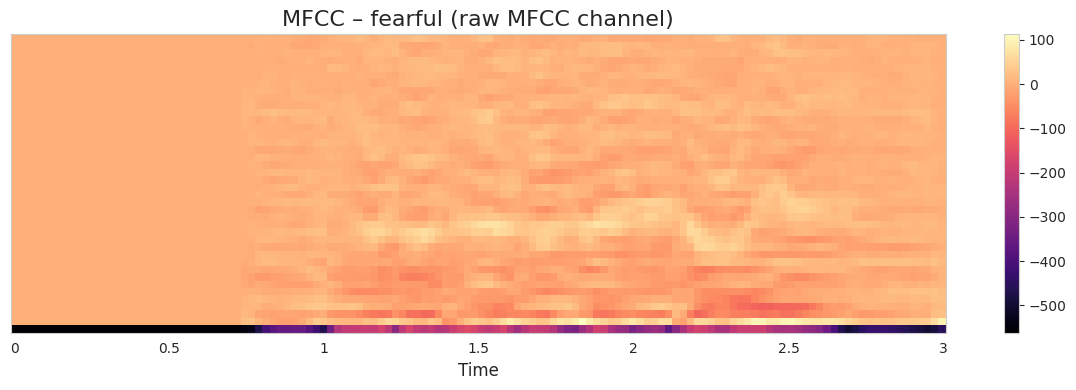

🔹 Train: (2304, 130, 40, 3), (2304, 8)
🔹 Validation: (288, 130, 40, 3), (288, 8)
🔹 Test: (288, 130, 40, 3), (288, 8)
🎭 Emotion classes: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]


In [ ]:
# ==============================================
# STEP 3: Feature Extraction – MFCCs
# ==============================================

import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import seaborn as sns

# ---------- 3.1 Configuration ----------
SAMPLE_RATE = 22050              # down-sample to 22.05 kHz (enough for speech)
N_MFCC = 40                      # number of MFCC coefficients to extract
FIXED_LENGTH = 3.0               # target duration in seconds (pad/truncate)
N_MELS = 128                     # mel bands
HOP_LENGTH = 512
N_FFT = 2048

# ---------- 3.2 Feature Extraction Function ----------
def extract_features(file_path, sr=SAMPLE_RATE, n_mfcc=N_MFCC,
                     fixed_length=FIXED_LENGTH, n_fft=N_FFT,
                     hop_length=HOP_LENGTH, n_mels=N_MELS):
    """
    Load audio, pad/truncate to fixed length, extract MFCCs + deltas.
    Returns a 2D array of shape (time_steps, n_mfcc*3) if using delta+delta2
    or (time_steps, n_mfcc) for raw MFCC.
    """
    # 1. Load and resample
    audio, _ = librosa.load(file_path, sr=sr)

    # 2. Force fixed length: truncate or pad
    target_length = int(sr * fixed_length)
    if len(audio) > target_length:
        audio = audio[:target_length]
    else:
        audio = np.pad(audio, (0, target_length - len(audio)), mode='constant')

    # 3. Compute MFCCs (time_steps, n_mfcc)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc,
                                n_fft=n_fft, hop_length=hop_length,
                                n_mels=n_mels)

    # 4. Compute delta (velocity) and delta-delta (acceleration)
    delta_mfcc = librosa.feature.delta(mfcc, width=9, order=1)
    delta2_mfcc = librosa.feature.delta(mfcc, width=9, order=2)

    # 5. Stack features along channel dimension (n_mfcc, time, 3)
    # We'll transpose to (time, n_mfcc, 3) for CNN, or (time, features_total) for LSTM
    features = np.stack([mfcc, delta_mfcc, delta2_mfcc], axis=-1)  # (n_mfcc, time, 3)
    features = features.transpose(1, 0, 2)  # (time, n_mfcc, 3)

    return features

# ---------- 3.3 Extract Features for All Files ----------
X, y = [], []
for idx, row in df.iterrows():
    features = extract_features(row['filepath'])
    X.append(features)
    y.append(row['emotion'])

X = np.array(X)  # shape: (n_samples, time_steps, n_mfcc, 3)
y = np.array(y)

print(f"✅ Feature matrix shape: {X.shape}")   # (1440, time_steps, 40, 3)
print(f"✅ Labels shape: {y.shape}")

# ---------- 3.4 Visualise a Single Feature Map ----------
sample_idx = 0
plt.figure(figsize=(12,4))
librosa.display.specshow(X[sample_idx, :, :, 0].T, x_axis='time', cmap='magma')
plt.colorbar()
plt.title(f"MFCC – {y[sample_idx]} (raw MFCC channel)")
plt.tight_layout()
plt.show()

# ---------- 3.5 Train / Validation / Test Split ----------
# We'll do a stratified split on emotion, respecting actors if you want
# But for simplicity, first random split (you can later improve)
X_flat = X  # keep the 4D shape for CNN input, or 3D for LSTM
y_labels = y

# Encode string labels to integers
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_labels)            # (1440,) integers 0..7
y_onehot = to_categorical(y_encoded, num_classes=8)   # (1440, 8)

# Split into train (80%), validation (10%), test (10%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_flat, y_onehot, test_size=0.2, random_state=42, stratify=y_encoded)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=np.argmax(y_temp, axis=1))

print(f"🔹 Train: {X_train.shape}, {y_train.shape}")
print(f"🔹 Validation: {X_val.shape}, {y_val.shape}")
print(f"🔹 Test: {X_test.shape}, {y_test.shape}")

# ---------- 3.6 Class Labels for Reference ----------
class_names = encoder.classes_
print(f"🎭 Emotion classes: {list(class_names)}")

## **2.4. Splitting and Preparing Data**


In [ ]:
# ==============================================
# STEP 4: Splitting and Prepare Data (Actor‑independent)
# ==============================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Ensure we have the 'actor' column from Step 2 and the features X, y from Step 3
# X shape: (1440, time_steps, 40, 3)
# y is the emotion strings, df has 'actor', 'emotion', etc.

# ---------- 4.1 Group actors and split ----------
unique_actors = df['actor'].unique()
n_actors = len(unique_actors)
print(f"Total actors: {n_actors}")   # 24

# Shuffle the actors randomly
np.random.seed(42)
np.random.shuffle(unique_actors)

# Split actors into train, validation, test (e.g., 16:4:4)
train_actors = unique_actors[:16]
val_actors = unique_actors[16:20]
test_actors = unique_actors[20:]

print("Train actors:", sorted(train_actors))
print("Validation actors:", sorted(val_actors))
print("Test actors:", sorted(test_actors))

# ---------- 4.2 Build masks and split the data ----------
train_mask = df['actor'].isin(train_actors)
val_mask = df['actor'].isin(val_actors)
test_mask = df['actor'].isin(test_actors)

X_train = X[train_mask]
y_train_str = y[train_mask]

X_val = X[val_mask]
y_val_str = y[val_mask]

X_test = X[test_mask]
y_test_str = y[test_mask]

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# ---------- 4.3 Encode labels ----------
# Fit the encoder ONLY on the training set (to avoid data leakage)
encoder = LabelEncoder()
y_train_enc = encoder.fit_transform(y_train_str)
y_val_enc = encoder.transform(y_val_str)
y_test_enc = encoder.transform(y_test_str)

num_classes = len(encoder.classes_)
print(f"Classes: {encoder.classes_}")

# Convert to one‑hot for categorical crossentropy
y_train = to_categorical(y_train_enc, num_classes)
y_val = to_categorical(y_val_enc, num_classes)
y_test = to_categorical(y_test_enc, num_classes)

print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"y_test shape: {y_test.shape}")

# ---------- 4.4 Check class distribution in each split ----------
def show_distribution(y_onehot, split_name):
    counts = np.sum(y_onehot, axis=0).astype(int)
    dist_df = pd.DataFrame({'Emotion': encoder.classes_, 'Count': counts})
    print(f"\n--- {split_name} Distribution ---")
    print(dist_df.to_string(index=False))

show_distribution(y_train, "Train")
show_distribution(y_val, "Validation")
show_distribution(y_test, "Test")

# ---------- 4.5 Data ready – no further reshaping needed for our CNN ----------
print(f"\n✅ X_train shape: {X_train.shape}  (samples, time, mfcc, channels)")
print(f"✅ X_val shape:   {X_val.shape}")
print(f"✅ X_test shape:  {X_test.shape}")
print("✅ Data is ready for model training!")

Total actors: 24
Train actors: [np.int64(1), np.int64(3), np.int64(5), np.int64(7), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(17), np.int64(19), np.int64(20), np.int64(22), np.int64(23), np.int64(24)]
Validation actors: [np.int64(6), np.int64(8), np.int64(15), np.int64(16)]
Test actors: [np.int64(2), np.int64(4), np.int64(18), np.int64(21)]

Train set: 1920 samples
Validation set: 480 samples
Test set: 480 samples
Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']
y_train shape: (1920, 8)
y_val shape: (480, 8)
y_test shape: (480, 8)

--- Train Distribution ---
  Emotion  Count
    angry    256
     calm    256
  disgust    256
  fearful    256
    happy    256
  neutral    128
      sad    256
surprised    256

--- Validation Distribution ---
  Emotion  Count
    angry     64
     calm     64
  disgust     64
  fearful     64
    happy     64
  neutral     32
      sad     64
surprised     64

--- Test Dis

## **2.5. Building Deep Learning Model**


In [ ]:
# ==============================================
# STEP 5: Building Deep Learning Model
# ==============================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization,
    Flatten, Dense, Dropout, Input
)
from tensorflow.keras.optimizers import Adam

# ---------- 5.1 Define Model Architecture ----------
def build_cnn_model(input_shape, num_classes=8):
    """
    Builds a 2D CNN for emotion recognition from MFCC features.
    Args:
        input_shape: (time_steps, n_mfcc, channels) e.g., (130, 40, 3)
        num_classes: number of emotions
    Returns:
        Compiled Keras model
    """
    model = Sequential(name="EmotionRecognition_CNN")

    # Block 1
    model.add(Conv2D(64, (3,3), padding='same', activation='relu',
                     input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.3))

    # Block 2
    model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.3))

    # Block 3 (deeper features)
    model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.4))

    # Flatten and fully connected layers
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    return model

# ---------- 5.2 Create the model ----------
# Get input shape from X_train (ignore batch dimension)
input_shape = X_train.shape[1:]   # e.g., (130, 40, 3)
num_classes = y_train.shape[1]    # 8

model = build_cnn_model(input_shape, num_classes)

# ---------- 5.3 Compile the model ----------
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ---------- 5.4 Model Summary ----------
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "EmotionRecognition_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 130, 40, 64)    │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 130, 40, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 65, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 65, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 65, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 65, 20, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 5, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 5, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20480)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,621,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,995,720 (11.43 MB)

 Trainable params: 2,994,568 (11.42 MB)

 Non-trainable params: 1,152 (4.50 KB)

## **2.6. Training the Model**


🚀 Starting training...
Epoch 1/100
57/60 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1610 - loss: 3.0648
Epoch 1: val_accuracy improved from None to 0.21667, saving model to best_emotion_model.keras

Epoch 1: finished saving model to best_emotion_model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - accuracy: 0.1990 - loss: 2.8256 - val_accuracy: 0.2167 - val_loss: 2.1148 - learning_rate: 1.0000e-04
Epoch 2/100
58/60 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2524 - loss: 2.4284
Epoch 2: val_accuracy improved from 0.21667 to 0.22917, saving model to best_emotion_model.keras

Epoch 2: finished saving model to best_emotion_model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.2818 - loss: 2.2513 - val_accuracy: 0.2292 - val_loss: 1.9847 - learning_rate: 1.0000e-04
Epoch 3/100
57/60 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3527 - loss: 1.9744
Epoch 3: val_accuracy improved from 0.22917 to 0.39167, saving model to best_emotion_model.keras

Epoch 3: finished sav

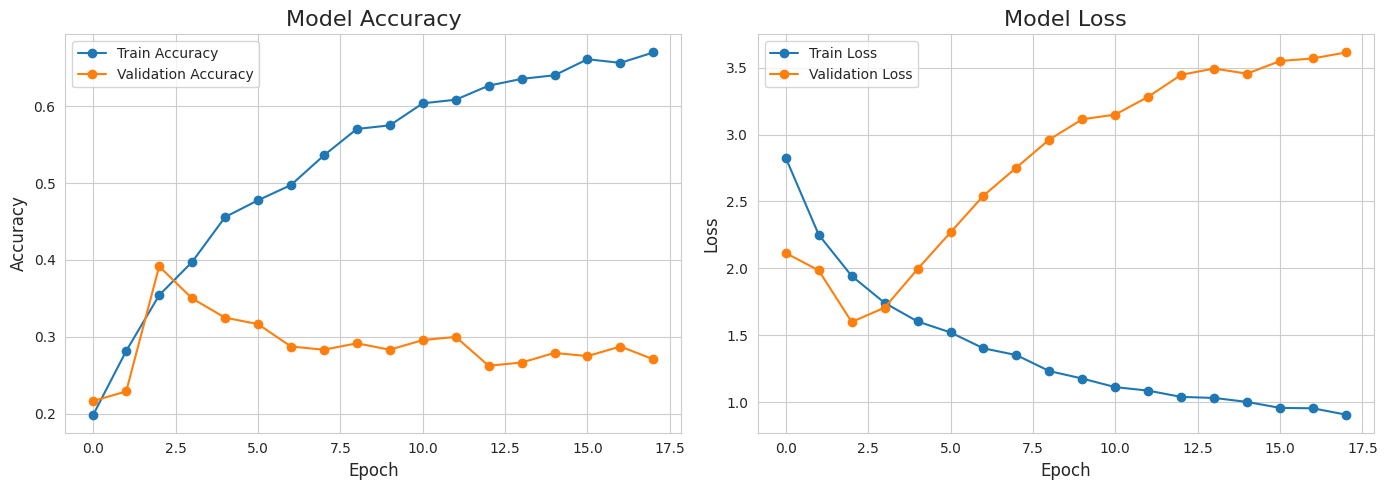

🔹 Best model (by val_accuracy) loaded from disk.


In [ ]:
# ==============================================
# STEP 6: Training the Model
# ==============================================

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt

# ---------- 6.1 Define callbacks ----------
callbacks = [
    # Stop training if validation loss doesn't improve for 15 epochs
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    # Save the best model during training (overwrite)
    ModelCheckpoint(
        filepath='best_emotion_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    # Reduce learning rate when validation loss plateaus
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

# ---------- 6.2 Train the model ----------
print("🚀 Starting training...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,                 # high number, early stopping will kick in
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)
print("✅ Training complete.")

# ---------- 6.3 Plot training & validation curves ----------
def plot_history(history):
    """Plots accuracy and loss curves from training history."""
    # Accuracy
    plt.figure(figsize=(14,5))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss', marker='o')
    plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_history(history)

# ---------- 6.4 Load the best saved model ----------
from tensorflow.keras.models import load_model
best_model = load_model('best_emotion_model.keras')
print("🔹 Best model (by val_accuracy) loaded from disk.")

## **2.7. Evaluating the Model**


✅ Best model loaded.
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

🎯 Test Accuracy: 0.3500 (35.00%)

📊 Classification Report:
              precision    recall  f1-score   support

       angry       0.27      0.94      0.42        64
        calm       1.00      0.12      0.22        64
     disgust       0.36      0.44      0.39        64
     fearful       0.75      0.47      0.58        64
       happy       0.00      0.00      0.00        64
     neutral       0.00      0.00      0.00        32
         sad       0.35      0.34      0.35        64
   surprised       0.31      0.31      0.31        64

    accuracy                           0.35       480
   macro avg       0.38      0.33      0.28       480
weighted avg       0.41      0.35      0.30       480



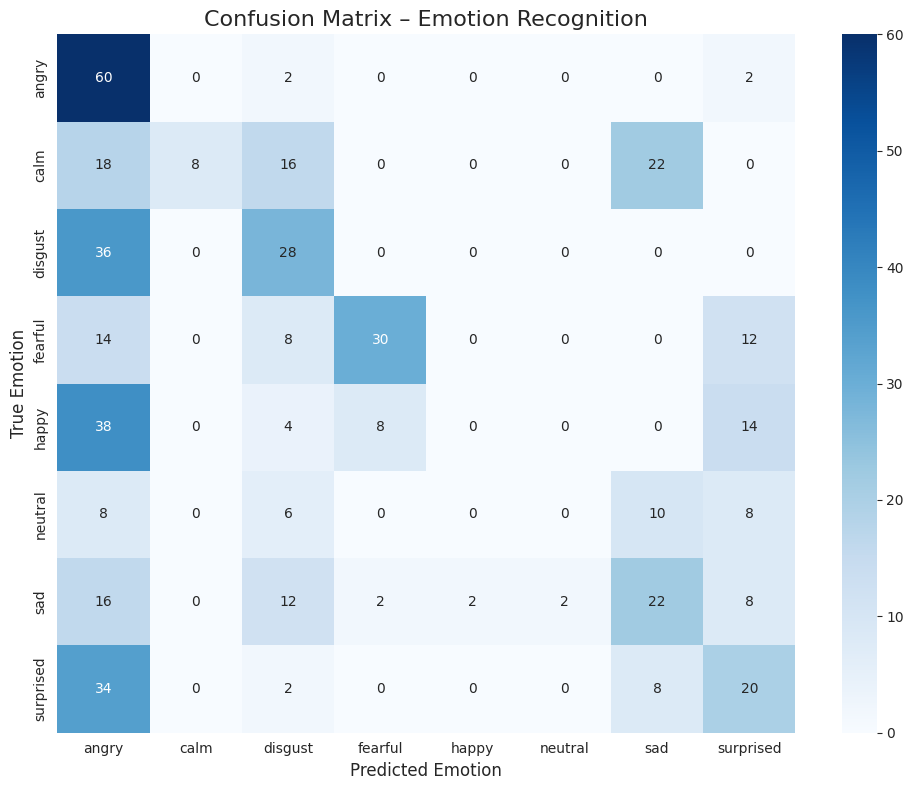

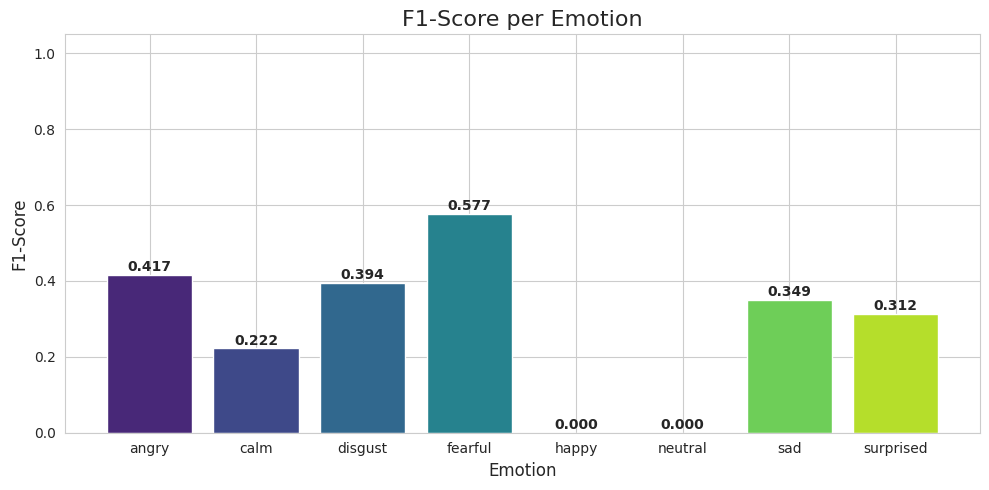


🎤 LIVE TEST: Upload a .wav file to predict its emotion:


Saving Kya Maal Hai Yaar Meme Audio Download Mp3.mp3 to Kya Maal Hai Yaar Meme Audio Download Mp3.mp3
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 591ms/step

🎭 Predicted Emotion: **DISGUST** (confidence: 48.3%)


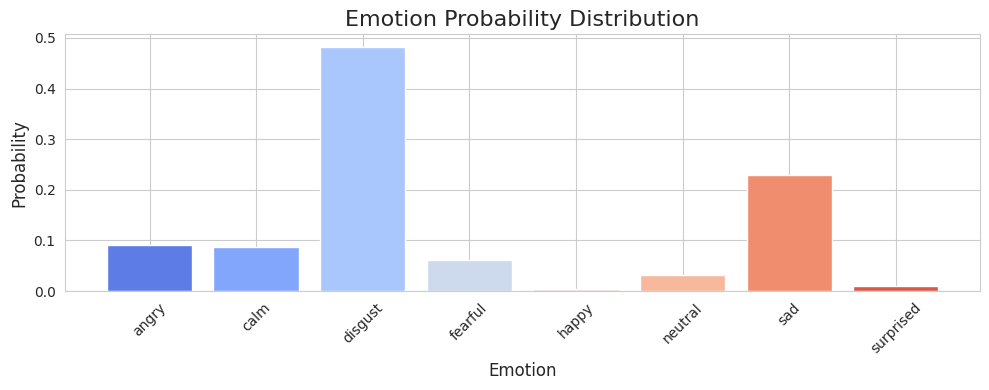

In [ ]:
# ==============================================
# STEP 7: Evaluating the Model
# ==============================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import load_model
import librosa
from IPython.display import Audio, display
from google.colab import files

# ---------- 7.1 Load the best model (if not already in memory) ----------
best_model = load_model('best_emotion_model.keras')
print("✅ Best model loaded.")

# ---------- 7.2 Predict on test set ----------
y_pred_probs = best_model.predict(X_test)           # (n_test, 8)
y_pred_enc = np.argmax(y_pred_probs, axis=1)        # integer labels
y_test_enc = np.argmax(y_test, axis=1)              # integer labels

# Convert integers back to emotion names
pred_emotions = encoder.inverse_transform(y_pred_enc)
true_emotions = encoder.inverse_transform(y_test_enc)

# ---------- 7.3 Overall accuracy ----------
test_acc = accuracy_score(y_test_enc, y_pred_enc)
print(f"\n🎯 Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# ---------- 7.4 Classification report ----------
print("\n📊 Classification Report:")
print(classification_report(true_emotions, pred_emotions, target_names=class_names))

# ---------- 7.5 Confusion matrix (heatmap) ----------
cm = confusion_matrix(true_emotions, pred_emotions, labels=class_names)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix – Emotion Recognition')
plt.xlabel('Predicted Emotion')
plt.ylabel('True Emotion')
plt.tight_layout()
plt.show()

# ---------- 7.6 Per-class F1-scores (bar chart) ----------
report_dict = classification_report(true_emotions, pred_emotions,
                                    target_names=class_names, output_dict=True)
f1_scores = [report_dict[emotion]['f1-score'] for emotion in class_names]
plt.figure(figsize=(10, 5))
bars = plt.bar(class_names, f1_scores, color=sns.color_palette('viridis', len(class_names)))
plt.ylim(0, 1.05)
plt.title('F1-Score per Emotion')
plt.xlabel('Emotion')
plt.ylabel('F1-Score')
# Add value labels on bars
for bar, v in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# ---------- 7.7 Live test: upload your own audio file ----------
print("\n🎤 LIVE TEST: Upload a .wav file to predict its emotion:")
uploaded = files.upload()

if uploaded:
    # Take the first uploaded file
    test_filename = list(uploaded.keys())[0]

    # Extract features using the exact same function from Step 3
    test_features = extract_features(test_filename)   # shape (time, n_mfcc, 3)
    test_features = np.expand_dims(test_features, axis=0)  # (1, time, n_mfcc, 3)

    # Predict
    pred_probs = best_model.predict(test_features)[0]
    predicted_idx = np.argmax(pred_probs)
    predicted_emotion = encoder.inverse_transform([predicted_idx])[0]
    confidence = pred_probs[predicted_idx] * 100

    # Show results
    print(f"\n🎭 Predicted Emotion: **{predicted_emotion.upper()}** (confidence: {confidence:.1f}%)")

    # Plot probability bars
    plt.figure(figsize=(10, 4))
    plt.bar(class_names, pred_probs, color=sns.color_palette('coolwarm', len(class_names)))
    plt.title('Emotion Probability Distribution')
    plt.xlabel('Emotion')
    plt.ylabel('Probability')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Play the uploaded audio for verification
    audio_sample, sr = librosa.load(test_filename, sr=22050)
    display(Audio(audio_sample, rate=sr))

## **2.8. Live Testing**


🎤 Choose a test file:
   • Upload a .wav file, or
   • Just press 'Cancel' to use a random dataset sample.



Saving Kya Maal Hai Yaar Meme Audio Download Mp3.mp3 to Kya Maal Hai Yaar Meme Audio Download Mp3 (2).mp3
✅ Using uploaded file: Kya Maal Hai Yaar Meme Audio Download Mp3 (2).mp3

📁 File: Kya Maal Hai Yaar Meme Audio Download Mp3 (2).mp3
   Original sample rate: 44100 Hz
   Duration: 1.35 seconds


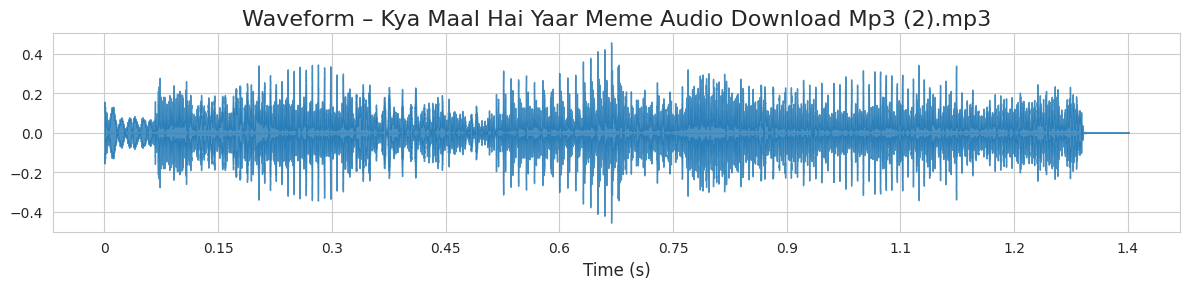


🎭  PREDICTED EMOTION: **DISGUST**
   Confidence: 48.3%


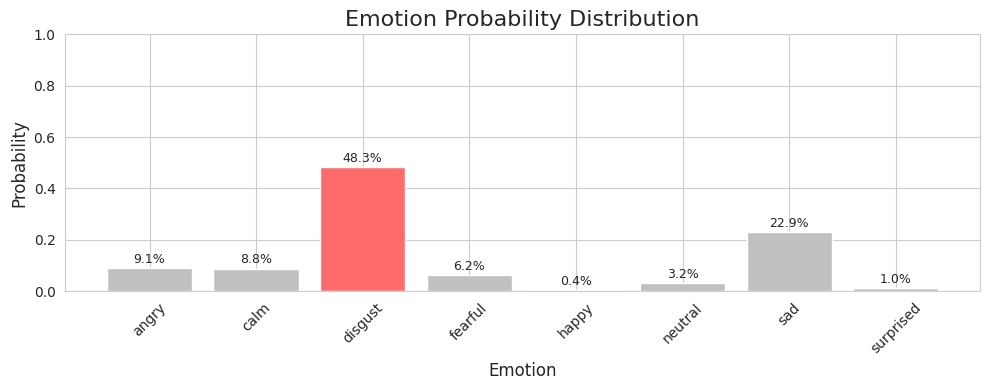

🔊 Playing back the test audio:



✅ Live test complete. Run this cell again to try another sample.


In [ ]:
# ==============================================
# STEP 8: Live Testing (Upload OR Dataset Sample)
# ==============================================

import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from IPython.display import Audio, display
from google.colab import files
import random
import warnings
warnings.filterwarnings('ignore')

# ---------- Re-define extract_features if missing ----------
try:
    _ = extract_features
except NameError:
    SAMPLE_RATE = 22050
    N_MFCC = 40
    FIXED_LENGTH = 3.0
    N_FFT = 2048
    HOP_LENGTH = 512
    N_MELS = 128

    def extract_features(file_path, sr=SAMPLE_RATE, n_mfcc=N_MFCC,
                         fixed_length=FIXED_LENGTH, n_fft=N_FFT,
                         hop_length=HOP_LENGTH, n_mels=N_MELS):
        audio, _ = librosa.load(file_path, sr=sr)
        target_length = int(sr * fixed_length)
        if len(audio) > target_length:
            audio = audio[:target_length]
        else:
            audio = np.pad(audio, (0, target_length - len(audio)), mode='constant')
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc,
                                    n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
        delta_mfcc = librosa.feature.delta(mfcc, width=9, order=1)
        delta2_mfcc = librosa.feature.delta(mfcc, width=9, order=2)
        features = np.stack([mfcc, delta_mfcc, delta2_mfcc], axis=-1)
        features = features.transpose(1, 0, 2)  # (time, n_mfcc, 3)
        return features

print("🎤 Choose a test file:")
print("   • Upload a .wav file, or")
print("   • Just press 'Cancel' to use a random dataset sample.\n")

uploaded = files.upload()

if uploaded:
    test_filename = list(uploaded.keys())[0]
    print(f"✅ Using uploaded file: {test_filename}")
else:
    # Pick a random sample from the dataset (df must be defined)
    random_idx = random.randint(0, len(df)-1)
    test_filename = df['filepath'].iloc[random_idx]
    print(f"ℹ️  No file uploaded – using random dataset sample:")
    print(f"   File: {os.path.basename(test_filename)}")
    print(f"   True emotion (for you to check): {df['emotion'].iloc[random_idx].upper()}")

# ---------- Load audio & display waveform ----------
raw_audio, raw_sr = librosa.load(test_filename, sr=None)
print(f"\n📁 File: {test_filename}")
print(f"   Original sample rate: {raw_sr} Hz")
print(f"   Duration: {len(raw_audio)/raw_sr:.2f} seconds")

plt.figure(figsize=(12, 3))
librosa.display.waveshow(raw_audio, sr=raw_sr, alpha=0.8)
plt.title(f"Waveform – {os.path.basename(test_filename)}")
plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

# ---------- Extract features & predict ----------
features = extract_features(test_filename)
features = np.expand_dims(features, axis=0)

pred_probs = best_model.predict(features, verbose=0)[0]
predicted_idx = np.argmax(pred_probs)
predicted_emotion = encoder.inverse_transform([predicted_idx])[0]
confidence = pred_probs[predicted_idx] * 100

print(f"\n{'='*50}")
print(f"🎭  PREDICTED EMOTION: **{predicted_emotion.upper()}**")
print(f"   Confidence: {confidence:.1f}%")
print(f"{'='*50}")

# ---------- Probability bar chart ----------
plt.figure(figsize=(10, 4))
colors = ['#ff6b6b' if i == predicted_idx else '#c0c0c0' for i in range(len(class_names))]
plt.bar(class_names, pred_probs, color=colors)
plt.ylim(0, 1)
plt.title('Emotion Probability Distribution')
plt.xlabel('Emotion')
plt.ylabel('Probability')
plt.xticks(rotation=45)
for i, prob in enumerate(pred_probs):
    plt.text(i, prob + 0.02, f'{prob*100:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# ---------- Play audio ----------
print("🔊 Playing back the test audio:")
display(Audio(raw_audio, rate=raw_sr))

print("\n✅ Live test complete. Run this cell again to try another sample.")